In [1]:
 # 1. Import Dependencies
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import random


In [2]:
# Load the dataset
df = pd.read_csv("extracted_columns.csv")

# Prepare features and target
X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7',
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']

In [3]:
# Define evaluation and plotting function
def evaluate_and_plot(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} RMSE: {rmse:.4f}")
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} R^2: {r2:.4f}")
    
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()

# SVR fitness function using kfold cross-validation
def fitness_kfold_svr(individual, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmse_scores = []
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = make_pipeline(
            StandardScaler(),
            SVR(C=individual['C'], epsilon=individual['epsilon'], kernel=individual['kernel'])
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return -np.mean(rmse_scores)

# Genetic algorithm for SVR hyperparameter tuning using kfold CV
def genetic_algorithm_kfold_svr(X, y, generations=10, population_size=20, k=5):
    param_bounds = {
        'C': [0.1, 1000],
        'epsilon': [0.01, 1.0],
        'kernel': ['linear', 'rbf']
    }

    def create_individual():
        return {
            'C': random.uniform(param_bounds['C'][0], param_bounds['C'][1]),
            'epsilon': random.uniform(param_bounds['epsilon'][0], param_bounds['epsilon'][1]),
            'kernel': random.choice(param_bounds['kernel'])
        }

    def mutate(individual, mutation_rate=0.1):
        if random.random() < mutation_rate:
            individual['C'] += random.uniform(-10, 10)
            individual['C'] = np.clip(individual['C'], param_bounds['C'][0], param_bounds['C'][1])
        if random.random() < mutation_rate:
            individual['epsilon'] += random.uniform(-0.05, 0.05)
            individual['epsilon'] = np.clip(individual['epsilon'], param_bounds['epsilon'][0], param_bounds['epsilon'][1])
        if random.random() < mutation_rate:
            individual['kernel'] = random.choice(param_bounds['kernel'])
        return individual

    def crossover(parent1, parent2):
        child = {}
        for key in parent1.keys():
            child[key] = parent1[key] if random.random() > 0.5 else parent2[key]
        return child

    population = [create_individual() for _ in range(population_size)]
    for individual in population:
        individual['fitness'] = fitness_kfold_svr(individual, X, y, k=k)

    for gen in range(generations):
        new_population = []
        while len(new_population) < population_size:
            parent1 = random.choice(population)
            parent2 = random.choice(population)
            child = crossover(parent1, parent2)
            child = mutate(child)
            child['fitness'] = fitness_kfold_svr(child, X, y, k=k)
            new_population.append(child)
        population = new_population
        best = max(population, key=lambda ind: ind['fitness'])
        print(f"Generation {gen+1}, Best RMSE: {-best['fitness']:.4f}, Params: {best}")

    best_individual = max(population, key=lambda ind: ind['fitness'])
    return best_individual


In [4]:
# Run genetic algorithm to find best SVR hyperparameters
best_params = genetic_algorithm_kfold_svr(X, y)

Generation 1, Best RMSE: 0.0905, Params: {'C': 526.8937936836483, 'epsilon': 0.21788403647526838, 'kernel': 'linear', 'fitness': np.float64(-0.0905494803728361)}
Generation 2, Best RMSE: 0.0767, Params: {'C': 335.14950652386676, 'epsilon': np.float64(0.1846038228826049), 'kernel': 'linear', 'fitness': np.float64(-0.07671389440806331)}
Generation 3, Best RMSE: 0.0767, Params: {'C': 508.40489228798003, 'epsilon': np.float64(0.1846038228826049), 'kernel': 'linear', 'fitness': np.float64(-0.07671389440806331)}
Generation 4, Best RMSE: 0.0042, Params: {'C': 584.8343167107878, 'epsilon': np.float64(0.01), 'kernel': 'linear', 'fitness': np.float64(-0.004220495112449798)}
Generation 5, Best RMSE: 0.0042, Params: {'C': 584.8343167107878, 'epsilon': np.float64(0.01), 'kernel': 'linear', 'fitness': np.float64(-0.004220495112449798)}
Generation 6, Best RMSE: 0.0737, Params: {'C': 584.8343167107878, 'epsilon': np.float64(0.1772520275123756), 'kernel': 'linear', 'fitness': np.float64(-0.073667998925

In [5]:
# Train the final SVR model with best hyperparameters on full dataset
final_svr_model = make_pipeline(
    StandardScaler(),
    SVR(C=best_params['C'], epsilon=best_params['epsilon'], kernel=best_params['kernel'])
)
final_svr_model.fit(X, y)

,steps,"[('standardscaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0


GA-Optimized SVR with KFold RMSE: 0.0632
GA-Optimized SVR with KFold MAE: 0.0502
GA-Optimized SVR with KFold R^2: 0.9999


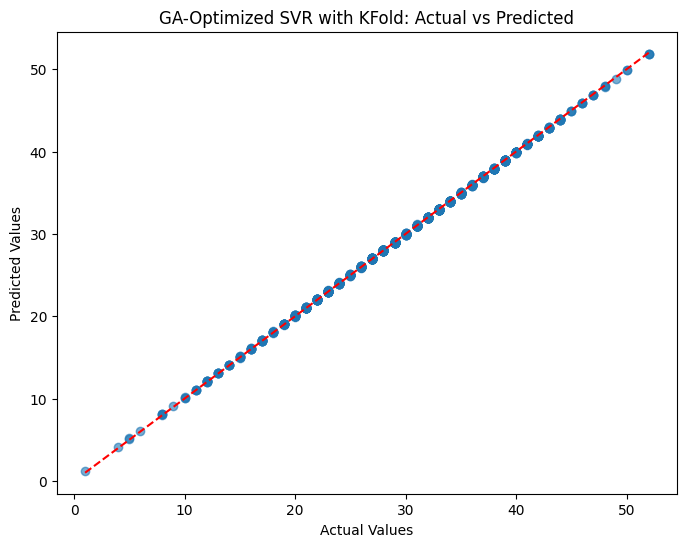

In [6]:
# Predict on full dataset and evaluate
y_pred = final_svr_model.predict(X)
evaluate_and_plot('GA-Optimized SVR with KFold', y, y_pred)